In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gym_members_exercise_tracking.csv')

In [3]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [5]:
# 1 Gender
#2 work out type

df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [6]:
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


<Axes: xlabel='Calories_Burned', ylabel='Count'>

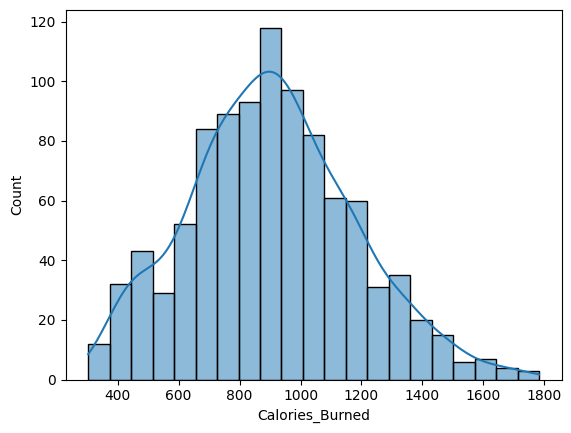

In [7]:
# cheking target columns for skewness
sns.histplot(df['Calories_Burned'],kde=True)

In [8]:
df['Calories_Burned'].skew()

np.float64(0.2783210950013363)

In [9]:
# correlation heatmap bw numerical features
corr = df.corr(numeric_only=True)

<Axes: >

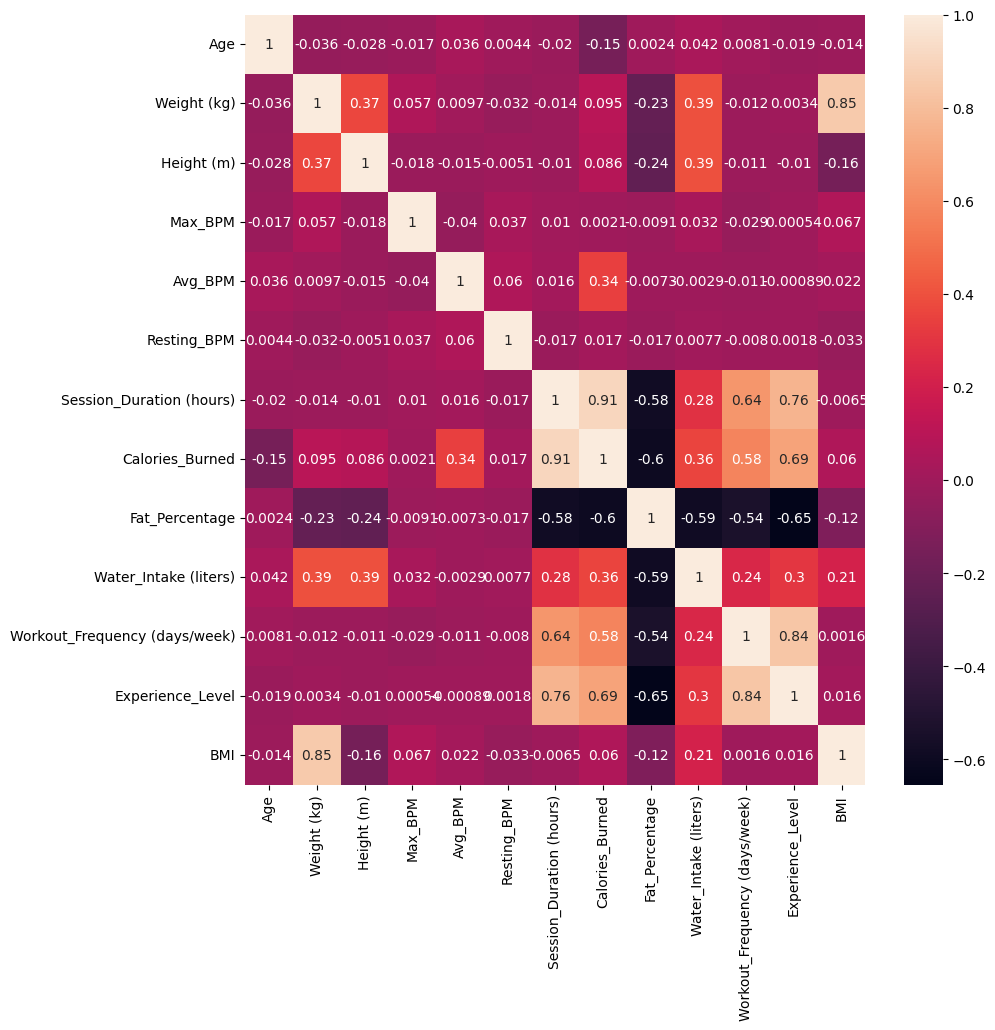

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)

In [11]:
# Gender , workout_type encode
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

In [12]:
# workout_type one hot Encode
df = pd.get_dummies(df,columns=['Workout_Type'])

In [13]:
# split x and y variables
X = df.drop(columns=['Calories_Burned'],axis=1)
y = df['Calories_Burned']

In [18]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # To prevent from data leakage


In [20]:
# build linear regression model
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)


LinearRegression()

In [21]:
y_pred = linear_model.predict(X_test)

In [22]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score(y_test,y_pred)

0.9802675995368527

In [23]:
r2_score(y_train,linear_model.predict(X_train))

0.9789133535430258

In [24]:
import joblib
joblib.dump(linear_model,'linear_model.pkl')

['linear_model.pkl']